In [1]:
import json, random
import numpy as np
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt

jsonl_path = "/glob/g01-cache/pf/Yushuo/vjepa201/data/embodiedscan_train.jsonl"
rows = [json.loads(l) for l in open(jsonl_path)]
print(f"Total rows: {len(rows)}")

Total rows: 63186


Query: facing the front of the telephone , pick the cabinet that is on the left of the telephone
Images: 4
Boxes: [[132.96723083698265, 267.2538466555694, 292.3547810902214, 443.6004710723858], [189.59963057898494, 204.87816146947588, 342.215665524544, 371.4112406779498], [246.83420806286227, 155.4659012859702, 400.41476878327813, 321.83878642463884], [326.8877736760925, 118.38110093876196, 491.3760783737696, 291.98281477111567]]


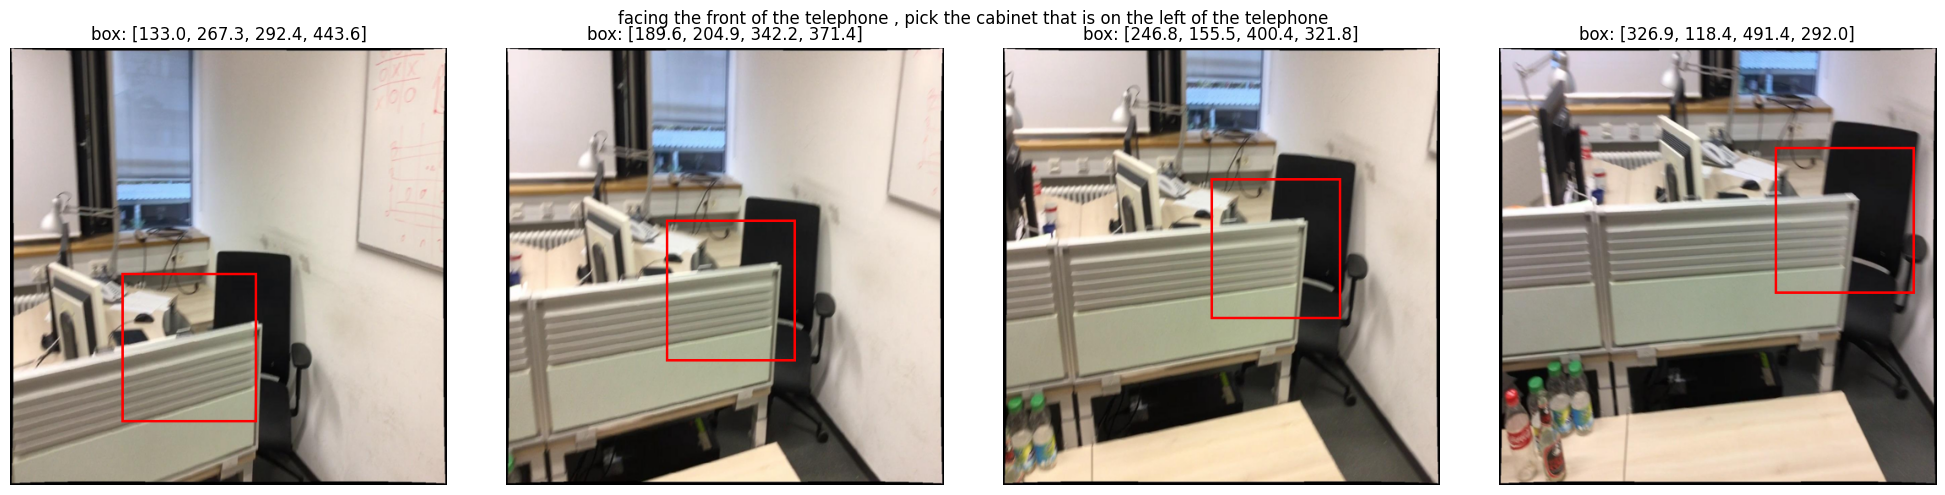

In [3]:
row = random.choice(rows)
print("Query:", row["query"])
print("Images:", len(row["images"]))
print("Boxes:", row["boxes"])

fig, axes = plt.subplots(1, len(row["images"]), figsize=(5*len(row["images"]), 5))
if len(row["images"]) == 1:
      axes = [axes]

for ax, img_path, box in zip(axes, row["images"], row["boxes"]):
      img = Image.open(img_path).convert("RGB")
      img = img.resize((518, 518))
      draw = ImageDraw.Draw(img)
      if box is not None:
          x1, y1, x2, y2 = box
          draw.rectangle([x1, y1, x2, y2], outline="red", width=3)
      ax.imshow(img)
      ax.set_title("box: " + (str([round(v,1) for v in box]) if box else "None"))
      ax.axis("off")

plt.suptitle(row["query"], fontsize=12)
plt.tight_layout()
plt.show()

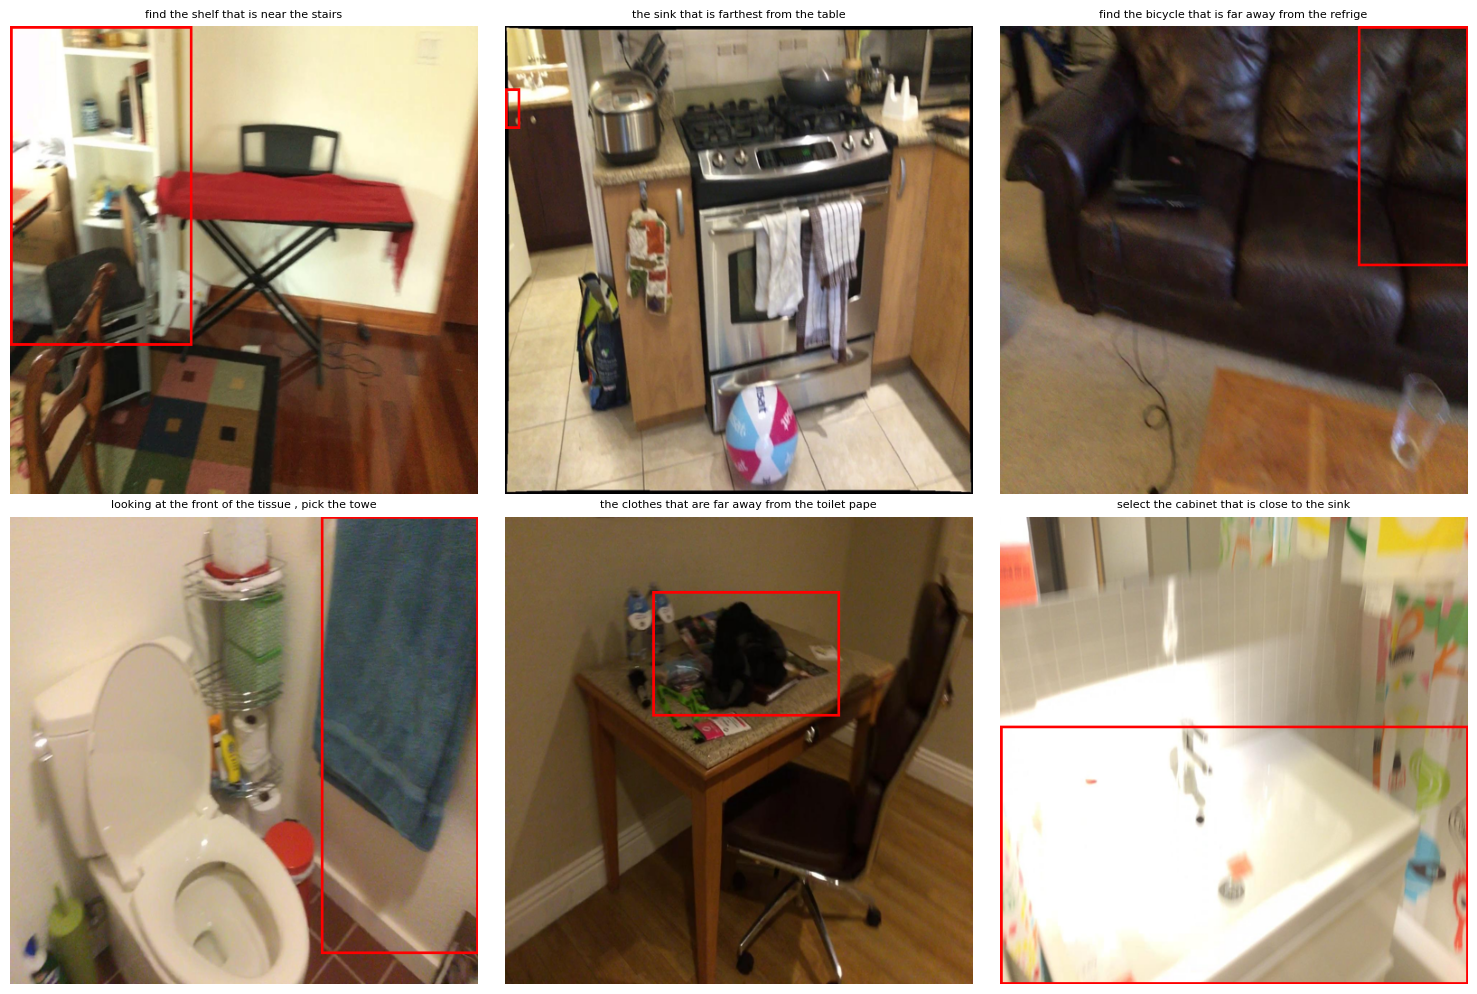

In [4]:
samples = random.sample(rows, 6)
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for ax, row in zip(axes.flat, samples):
      # 取第一帧有box的
      for img_path, box in zip(row["images"], row["boxes"]):
          if box is not None:
              img = Image.open(img_path).convert("RGB").resize((518, 518))
              draw = ImageDraw.Draw(img)
              draw.rectangle(box, outline="red", width=3)
              ax.imshow(img)
              ax.set_title(row["query"][:50], fontsize=8)
              ax.axis("off")
              break

plt.tight_layout()
plt.show()